In [1]:
import pandas as pd
import numpy as np
import keras
import tensorflow as tf

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
# get demand data from NTUST (sum from multiple building in NTUST)
power_df = pd.read_csv("../dataset/NTUST.csv", index_col=0, parse_dates=True)
power_df = power_df.asfreq('h') 
power_df = pd.DataFrame(power_df.loc[power_df.index.year!=2020, "KW"].round(2).copy())

In [3]:
power_df.tail()

,KW
timestamp,
2019-12-31 19:00:00,416.52
2019-12-31 20:00:00,413.42
2019-12-31 21:00:00,399.26
2019-12-31 22:00:00,387.49
2019-12-31 23:00:00,353.23


In [4]:
# get weather data from NSRDB (NSRDB.csv), if you want to get data from NASA, use NASA.csv
weather_df = pd.read_csv("../dataset/NSRDB.csv")
weather_df.index = power_df.index 

In [5]:
weather_df.tail()

,YEAR,MONTH,DAY,HOUR,TEMPERATURE,DEW_POINT,GHI,PRESSURE,WIND_SPEED,RELATIVE HUMIDITY,PRECIPITABLE WATER,CLOUD_TYPE
timestamp,,,,,,,,,,,,
2019-12-31 19:00:00,2019,12,31,19,16.3,12.7,0,1039,6.6,79.46,2.6,3
2019-12-31 20:00:00,2019,12,31,20,16.3,12.8,0,1039,6.5,79.67,2.6,3
2019-12-31 21:00:00,2019,12,31,21,16.3,12.9,0,1039,6.3,80.06,2.5,3
2019-12-31 22:00:00,2019,12,31,22,16.3,13.0,0,1039,6.1,80.74,2.4,3
2019-12-31 23:00:00,2019,12,31,23,16.3,13.1,0,1038,6.0,81.17,2.4,3


In [6]:
# select which weather features will be used
col_weather = ["TEMPERATURE", "GHI"]

# concatenate demand data with weather data
df = pd.concat([power_df, weather_df[col_weather]], axis=1)
col_selected = df.columns

In [7]:
# set training data using June, July, and August data
train_df = df.loc[power_df.index.month.isin([5, 6, 7]),]
# set testing data using September data
test_df  = df.loc[power_df.index.month.isin([8]),]

# Normalization
scaler = MinMaxScaler()
train_df = scaler.fit_transform(train_df)
test_df  = scaler.transform(test_df)

# set look back/historical/input data 
history_size = 24

# set how long ahead will be forecasted (> 1 means multi-step forecasting)
target_size  = 24 

# step between interval
step = 1

In [8]:
def multivariate_multioutput_data(dataset, target, start_index, end_index, history_size,
                      target_size, step, single_step=False):
    data = []
    labels = []

    start_index = start_index + history_size
    if end_index is None:
        end_index = len(dataset) - target_size

    for i in range(start_index, end_index):
        indices = range(i - history_size, i, step)
        data.append(dataset[indices])

        if single_step:
            labels.append(target[i + target_size])
        else:
            labels.append(target[i: i + target_size])

    return np.array(data)[:, :, :, np.newaxis, np.newaxis], np.array(labels)[:, :, :, np.newaxis, np.newaxis]

In [9]:
# transform training data into predictors and target
X_train, y_train = multivariate_multioutput_data(dataset=train_df, target=train_df, 
                                                 start_index=0, end_index=None, 
                                                 history_size=24, target_size=24, 
                                                 step=1, single_step=False)

X_train, y_train = X_train.reshape(-1, history_size, train_df.shape[1]), y_train.reshape(-1, history_size, train_df.shape[1])

X_test, y_test   = multivariate_multioutput_data(dataset=test_df, target=test_df, 
                                                 start_index=0, end_index=None, 
                                                 history_size=24, target_size=24, 
                                                 step=1, single_step=False)

X_test, y_test   = X_test.reshape(-1, history_size, train_df.shape[1]), y_test.reshape(-1, history_size, train_df.shape[1])

In [10]:
print(f'x train shape: {X_train.shape}, y train shape: {y_train.shape}')
print(f'x test shape: {X_test.shape}, y test shape: {y_test.shape}')

x train shape: (2160, 24, 3), y train shape: (2160, 24, 3)
x test shape: (696, 24, 3), y test shape: (696, 24, 3)


In [11]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Attention and Normalization
    x = keras.layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs

    # Feed Forward Part
    x = keras.layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(res)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x)
    return x + res


class ExpandDims(keras.layers.Layer):
    def __init__(self, axis, **kwargs):
        super(ExpandDims, self).__init__(**kwargs)
        self.axis = axis

    def call(self, inputs):
        return tf.expand_dims(inputs, axis=self.axis)
    

def build_model(
    n_input: int,
    n_output: int,
    num_features: int,
    head_size: int,
    num_heads: int,
    ff_dim: int,
    num_transformer_blocks: int,
    mlp_units,              
    dropout=0.1,            # slightly smaller dropout
    mlp_dropout=0.1
):
    inputs = keras.Input(shape=(n_input, num_features))
    x = inputs
    
    # --- LSTM Encoder ---
    x = tf.keras.layers.LayerNormalization(epsilon=1e-6)(x) 
    x = keras.layers.LSTM(
        units=32, return_sequences=True, name="lstm_encoder_hidden1"
    )(x)
    x = keras.layers.LSTM(
        units=32, return_sequences=True, name="lstm_encoder_hidden2"
    )(x)
    x = keras.layers.Dropout(dropout)(x)
    x, state_h, state_c = keras.layers.LSTM(
        units=32, return_sequences=True, return_state=True, name="lstm_encoder"
    )(x)
    
    # --- Transformer Encoder Blocks ---
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)
    
    # Pool & reshape before decoder
    x = keras.layers.GlobalAveragePooling1D(data_format="channels_last")(x)
    x = ExpandDims(axis=1)(x)
    
    # --- LSTM Decoder ---
    x = keras.layers.LSTM(
        units=32, return_sequences=True, name="lstm_decoder_hidden1"
    )(x, initial_state=[state_h, state_c])

    x = keras.layers.LayerNormalization(epsilon=1e-6)(x)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.LSTM(
        units=32, return_sequences=False, name="lstm_decoder_final"
    )(x)
    
    # --- MLP “head” ---
    for dim in mlp_units:
        x = keras.layers.Dense(dim, activation="relu")(x)
        x = keras.layers.Dropout(mlp_dropout)(x)

    # Use 'relu' if target is strictly nonnegative
    # outputs = keras.layers.Dense(n_output, activation="relu")(x)
    outputs = keras.layers.Dense(n_output * num_features, activation="relu")(x)
    outputs = keras.layers.Reshape((n_output, num_features))(outputs)
    
    return keras.Model(inputs, outputs)

In [12]:
model = build_model(
    n_input=history_size,
    n_output=target_size,
    num_features=X_train.shape[2],
    head_size=64,
    num_heads=4,
    ff_dim=10,         
    num_transformer_blocks=4, 
    mlp_units=[32, 16],
    mlp_dropout=0.1,
    dropout=0.1
)

In [13]:
optimizer = keras.optimizers.Adam(learning_rate=1e-3)

model.compile(
    loss="mean_squared_error",
    optimizer=optimizer,
    metrics=[
        "mae",
        tf.keras.metrics.RootMeanSquaredError(name="rmse"),
        tf.keras.metrics.MeanAbsolutePercentageError(name="mape")
    ]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 24, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 24, 3)     │          6 │ input_layer[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_encoder_hidde… │ (None, 24, 32)    │      4,608 │ layer_normalizat… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_encoder_hidde… │ (None, 24, 32)    │      8,320 │ lstm_encoder_hid… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 32)    │          0 │ lstm_encoder_hid… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_encoder (LSTM) │ [(None, 24, 32),  │      8,320 │ dropout[0][0]     │
│                     │ (None, 32),       │            │                   │
│                     │ (None, 32)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 32)    │     33,568 │ lstm_encoder[0][… │
│ (MultiHeadAttentio… │                   │            │ lstm_encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 24, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 32)    │         64 │ dropout_2[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ lstm_encoder[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 24, 10)    │        330 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 24, 10)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 24, 32)    │        352 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 32)    │         64 │ conv1d_1[0][0]    │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 32)    │     33,568 │ add_1[0][0],      │
│ (MultiHeadAttentio… │                   │            │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 24, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 32)    │         64 │ dropout_5[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 178,278 (696.40 KB)

 Trainable params: 178,278 (696.40 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    min_lr=1e-6
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=15,
    validation_split=0.2,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        lr_scheduler
    ]
)


Epoch 1/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.1477 - mae: 0.3015 - mape: 15009730.0000 - rmse: 0.3833 - val_loss: 0.1061 - val_mae: 0.2477 - val_mape: 25186610.0000 - val_rmse: 0.3258 - learning_rate: 0.0010
Epoch 2/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0681 - mae: 0.1990 - mape: 23531526.0000 - rmse: 0.2607 - val_loss: 0.0610 - val_mae: 0.1974 - val_mape: 27525048.0000 - val_rmse: 0.2470 - learning_rate: 0.0010
Epoch 3/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0470 - mae: 0.1684 - mape: 24754022.0000 - rmse: 0.2168 - val_loss: 0.0539 - val_mae: 0.1800 - val_mape: 30023698.0000 - val_rmse: 0.2322 - learning_rate: 0.0010
Epoch 4/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0435 - mae: 0.1618 - mape: 25401682.0000 - rmse: 0.2085 - val_loss: 0.0498 - val_mae: 0.1711 - val_mape: 32599164.0000 - val_rmse: 0.2232 - learning_rate: 0.0010
Epoch 5/100
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.0433 - mae: 0.1641 - mape: 27513

In [15]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    metrics = ['loss', 'mae', 'rmse', 'mape']
    val_metrics = [f"val_{m}" for m in metrics]
    
    plt.figure(figsize=(14, 8))
    for i, metric in enumerate(metrics):
        plt.subplot(2, 2, i+1)
        plt.plot(history.history[metric], label=f"train_{metric}")
        plt.plot(history.history[val_metrics[i]], label=f"val_{metric}")
        plt.xlabel("Epoch")
        plt.ylabel(metric.upper())
        plt.legend()
        plt.title(f"{metric.upper()} per Epoch")
        plt.grid(True)
    
    plt.tight_layout()
    plt.show()

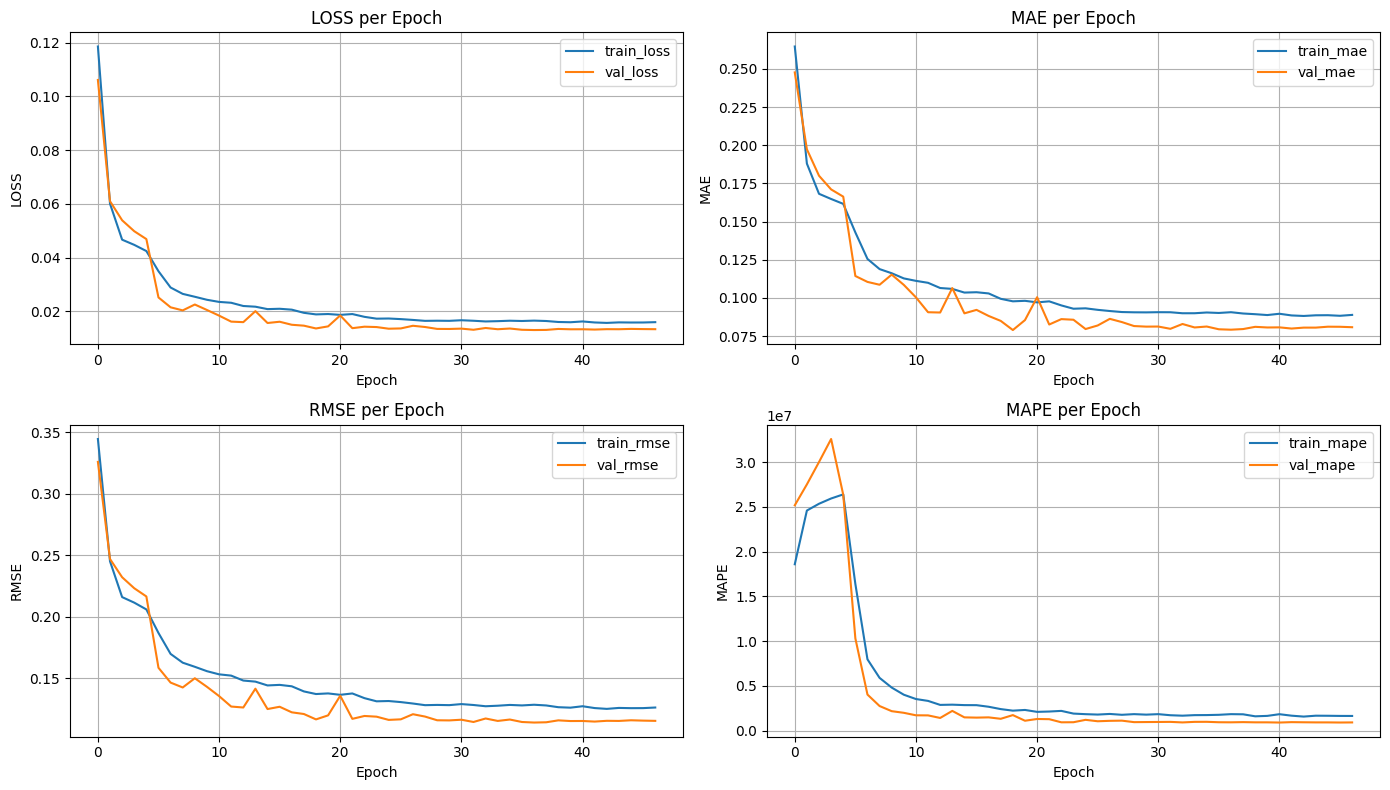

In [16]:
plot_training_history(history)

In [17]:
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error

def get_prediction(true, pred, hist, cols, index=0, name="Test"):
    error_mean_all_df = pd.DataFrame()
    result_col_selected, hist_col_selected = list(), list()
    for col_target in cols:
        error = list()
        for i in range(len(pred)):
            a = pd.DataFrame(scaler.inverse_transform(true[i,:,:]), 
                             columns=col_selected)
            b = pd.DataFrame(scaler.inverse_transform(pred[i,:,:]), 
                             columns=col_selected)
             
            result_df = pd.DataFrame({"true": a[col_target].to_numpy().ravel(), 
                                      "pred": b[col_target].to_numpy().ravel()})
            
            
            if i==index:
                result_col_selected.append(result_df)
                hist_col_selected = scaler.inverse_transform(hist[i, :, :])

            mae_test  = mean_absolute_error(result_df["true"], 
                                            result_df["pred"])
            mape_test = mean_absolute_percentage_error(result_df["true"], 
                                                       result_df["pred"])
            rmse_test = mean_squared_error(result_df["true"], 
                                           result_df["pred"])
            # print(i, col_target, "MAE :", round(mae_test,4))
            # print(i, col_target, "MAPE:", round(mape_test,4))
            # print(i, col_target, "RMSE:", round(rmse_test,4))
            
            error.append([round(mae_test, 4), round(mape_test, 4), round(rmse_test, 4)])
        error_df = pd.DataFrame(error, columns=[col_target+"_MAE_"+name, 
                                                col_target+"_MAPE_"+name, 
                                                col_target+"_RMSE_"+name]
                                )
        error_df.to_csv(col_target+"_"+name+"_ERROR.csv")
        error_mean_df = pd.DataFrame(error_df.mean()).T
        error_mean_df.to_csv(col_target+"_"+name+"_ERROR_MEAN.csv")
        error_mean_all_df = pd.concat([error_mean_all_df, error_mean_df], axis=1)
    
    error_mean_all_df.to_csv(col_target+"_"+name+"_ERROR_MEAN_ALL.csv")
    print(name)
    print(error_mean_all_df.loc[0])
    print()
    return error_df, error_mean_df, error_mean_all_df, result_col_selected, hist_col_selected

def plot_result(num_plots, result, history, name):
    fig, ax = plt.subplots(nrows=num_plots, ncols=1, sharex='all', figsize=(10,num_plots*3))         
    for idx in range(num_plots):
        temp_ds = result[idx]
        true = temp_ds["true"].to_numpy()
        pred = temp_ds["pred"].to_numpy()
        hist = history[:, idx]

        ax[idx].plot(list(range(-len(hist),0)), hist.ravel(), '.-', label='Inputs')
        ax[idx].plot(list(range(len(true))), true.ravel(), '--', c='#2ca02c')
        ax[idx].scatter(list(range(len(true))), true.ravel(),
                        label='Labels', c='#2ca02c', s=64, edgecolors='k')

        if pred.any():
            ax[idx].plot(pred.ravel(), '--', c='#ff7f0e')
            ax[idx].scatter(list(range(len(pred))), pred.ravel(),
                    marker='X', edgecolors='k', label='Predictions',
                    c='#ff7f0e', s=64)
            ax[idx].set_ylabel(col_selected[idx], fontsize=14)
        if idx==0:
            ax[idx].legend()
    ax[num_plots-1].set_xlabel('Time [Hour]', fontsize=14)

TRAIN
KW_MAE_TRAIN              5.856837e+01
KW_MAPE_TRAIN             1.099183e-01
KW_RMSE_TRAIN             5.506411e+03
TEMPERATURE_MAE_TRAIN     7.418592e-01
TEMPERATURE_MAPE_TRAIN    2.712009e-02
TEMPERATURE_RMSE_TRAIN    9.467742e-01
GHI_MAE_TRAIN             7.852595e+01
GHI_MAPE_TRAIN            9.022911e+15
GHI_RMSE_TRAIN            1.775785e+04
Name: 0, dtype: float64

TEST
KW_MAE_TEST              5.717920e+01
KW_MAPE_TEST             1.056647e-01
KW_RMSE_TEST             5.409796e+03
TEMPERATURE_MAE_TEST     7.444818e-01
TEMPERATURE_MAPE_TEST    2.497055e-02
TEMPERATURE_RMSE_TEST    8.849855e-01
GHI_MAE_TEST             9.483660e+01
GHI_MAPE_TEST            1.457879e+16
GHI_RMSE_TEST            2.413815e+04
Name: 0, dtype: float64



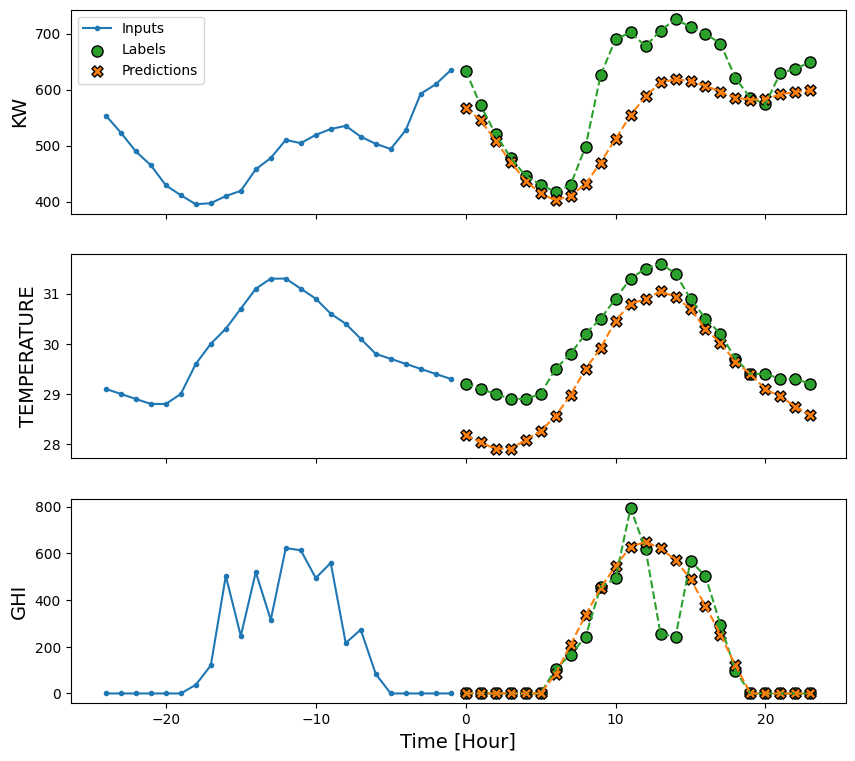

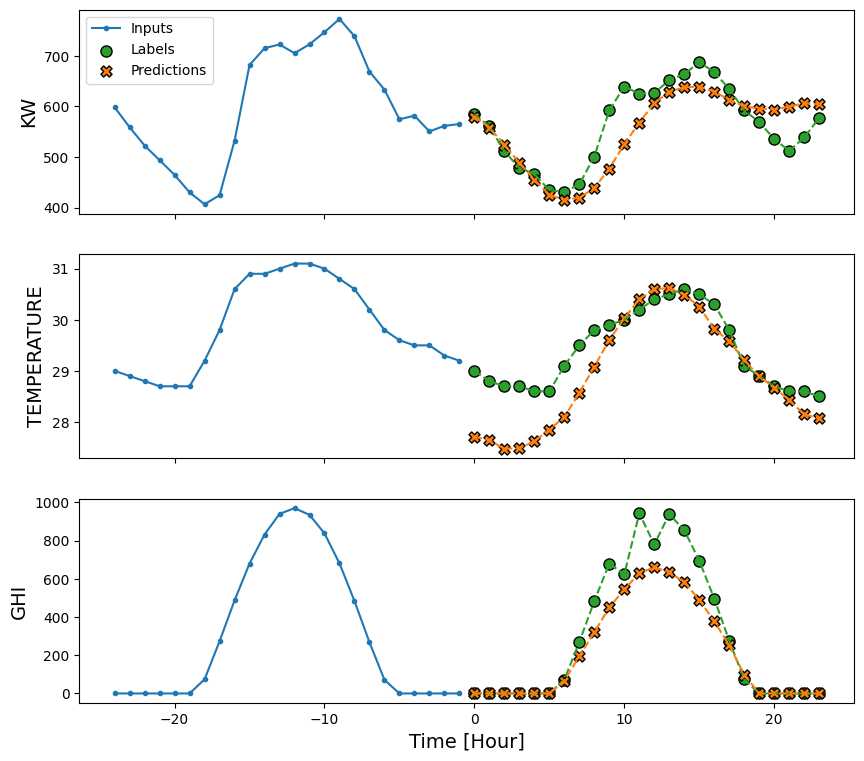

In [18]:
# to get training MAE, MAPE, and RMSE, and sample plot
name = "TRAIN"
index_sample_plot = 24*60 
y_train_pred = model.predict(X_train, verbose=0)
train_error_df, train_error_mean_df, train_error_mean_all_df, train_result_col_selected, train_hist_col_selected = get_prediction(y_train, y_train_pred, X_train, col_selected, index_sample_plot, name)
plot_result(num_plots=len(col_selected), result=train_result_col_selected, history=train_hist_col_selected, name=name)

# to get testing MAE, MAPE, and RMSE, and sample plot
name = "TEST"
index_sample_plot = 0 
y_test_pred = model.predict(X_test, verbose=0)
test_error_df, test_error_mean_df, test_error_mean_all_df, test_result_col_selected, test_hist_col_selected = get_prediction(y_test, y_test_pred, X_test, col_selected, index_sample_plot, name)
plot_result(num_plots=len(col_selected), result=test_result_col_selected, history=test_hist_col_selected, name=name)